In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [98]:
ratings = pd.read_csv("ratings.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [99]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

matrix = user_item_matrix.values / 5.0

In [100]:
model = NMF(n_components=30, init='nndsvd', random_state=42, max_iter=500)

W = model.fit_transform(matrix)   
H = model.components_             

In [101]:
reconstructed = np.dot(W, H)
reconstructed = np.clip(reconstructed, 0, 1)

In [102]:
mask = matrix > 0
actual = matrix[mask]
pred = reconstructed[mask]

rmse = np.sqrt(mean_squared_error(actual, pred))
print("RMSE:", rmse)

RMSE: 0.46804634738516415


In [103]:
K = 30
threshold = 0.7

precisions = []
recalls = []

for user_idx in range(matrix.shape[0]):
    actual_items = np.where(matrix[user_idx] >= threshold)[0]
    predicted_items = np.argsort(reconstructed[user_idx])[-K:]
    
    relevant_and_recommended = len(set(actual_items) & set(predicted_items))
    
    precision = relevant_and_recommended / K
    precisions.append(precision)
    
    if len(actual_items) > 0:
        recall = relevant_and_recommended / len(actual_items)
        recalls.append(recall)

print("Precision@K:", np.mean(precisions))
print("Recall@K:", np.mean(recalls))

Precision@K: 0.45535519125683055
Recall@K: 0.2554173380912848


In [104]:
user_id = user_item_matrix.index[0]
user_index = list(user_item_matrix.index).index(user_id)

user_ratings = reconstructed[user_index]
top_movies = np.argsort(user_ratings)[-10:][::-1]

print("\nTop Recommended Movie IDs:", top_movies)


Top Recommended Movie IDs: [1938  897  910  224  507  938  901 1502  899  989]


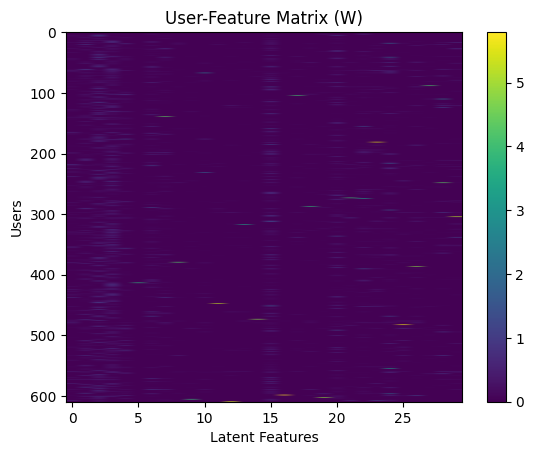

In [105]:
plt.figure()
plt.imshow(W, aspect='auto')
plt.title("User-Feature Matrix (W)")
plt.xlabel("Latent Features")
plt.ylabel("Users")
plt.colorbar()
plt.show()

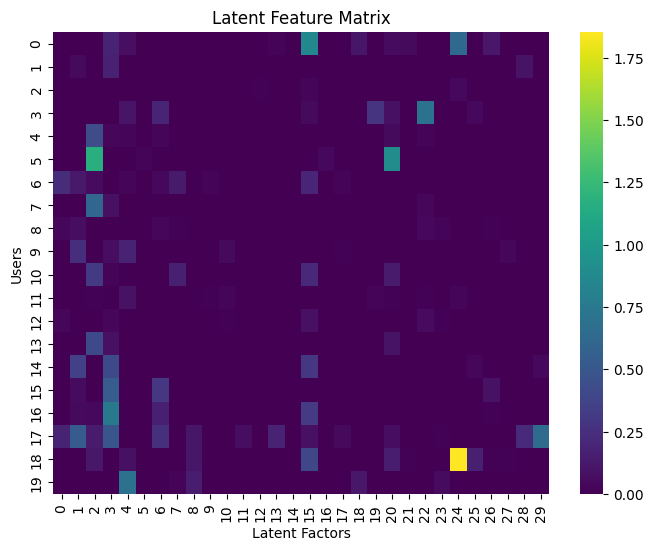

In [106]:
W_sample = W[:20, :]

plt.figure(figsize=(8,6))
sns.heatmap(W_sample, cmap='viridis')
plt.title("Latent Feature Matrix")
plt.xlabel("Latent Factors")
plt.ylabel("Users")
plt.show()

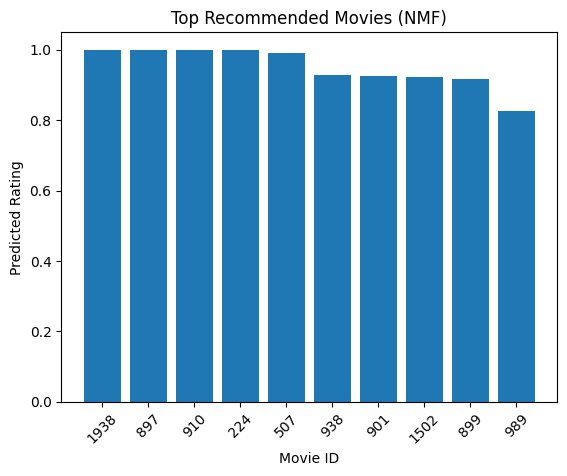

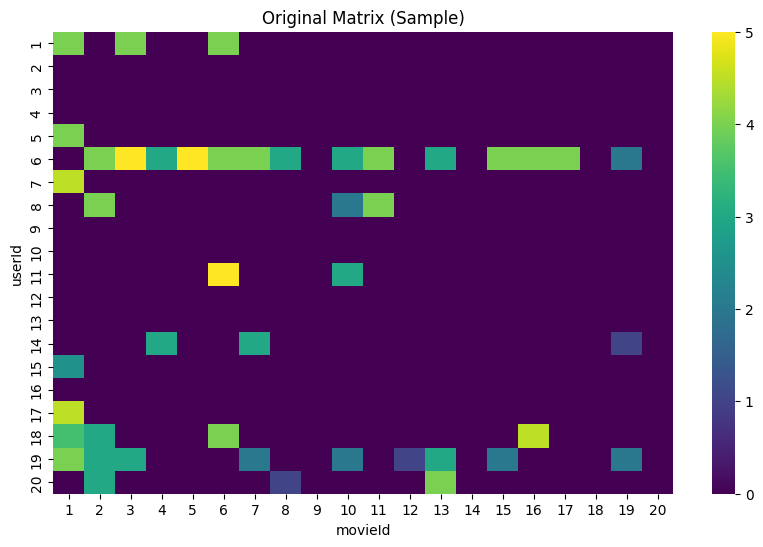

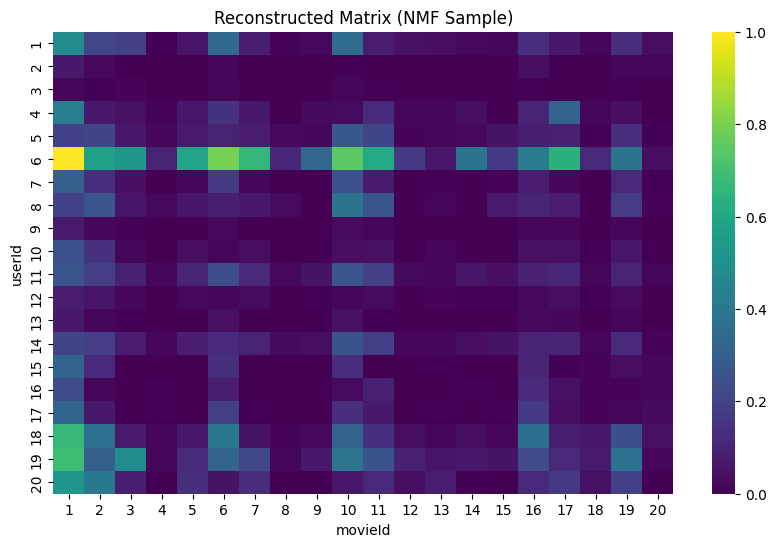

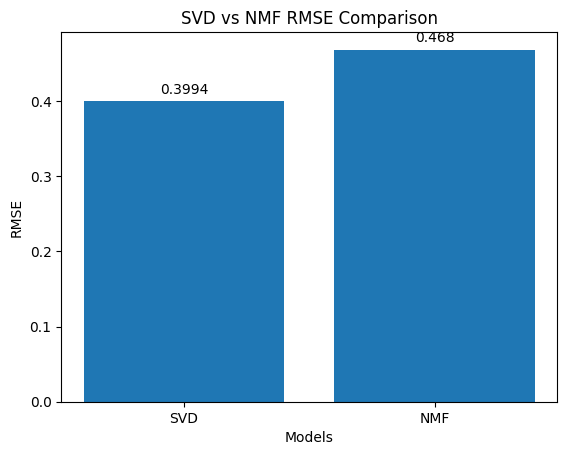

In [107]:
plt.figure()
plt.bar(range(len(top_movies)), user_ratings[top_movies])
plt.xticks(range(len(top_movies)), top_movies, rotation=45)
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.title("Top Recommended Movies (NMF)")
plt.show()

sample_users = user_item_matrix.iloc[:20, :20]

plt.figure(figsize=(10,6))
sns.heatmap(sample_users, cmap='viridis')
plt.title("Original Matrix (Sample)")
plt.show()

sample_reconstructed = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
).iloc[:20, :20]

plt.figure(figsize=(10,6))
sns.heatmap(sample_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (NMF Sample)")
plt.show()

models = ['SVD', 'NMF']
rmse_values = [0.3994, 0.4680]

plt.figure()
plt.bar(models, rmse_values)
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("SVD vs NMF RMSE Comparison")

for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.01, str(v), ha='center')

plt.show()